# Causal Inference in Economics: Does a Job‑Training Program Really Increase Employment?

This notebook applies the core ideas from **Chapter 2 — "First steps: Working with confounders"**
(Simpson's paradox, the adjustment formula, interventions, the Average Treatment Effect, and the
positivity assumption) to a realistic problem in **labor economics / public‑policy evaluation**.

### The economic question

A government agency ran a **job‑training program** for unemployed workers. Enrollment was
**voluntary** (not a randomized experiment), so we only have **observational data**: some people
chose to enroll in the program, others did not, and six months later we observe whether each
person is employed.

The agency wants to know:

> **"Did the training program actually cause an increase in employment, or does the raw data
> mislead us because of who chose to enroll?"**

This is *exactly* the kind of question the book warns us about: naive comparisons of averages
between "treated" and "untreated" groups can be **completely wrong** in observational data,
because of confounding — and this is precisely what we'll demonstrate, using the same
mathematical machinery as the kidney‑stone example (Simpson's paradox, the adjustment
formula, and the Average Treatment Effect / ATE), but now applied to **program evaluation**,
one of the most common tasks in applied economics (labor economics, development economics,
industrial organization, etc.).


## 0. Setup

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.random import default_rng

plt.rcParams['figure.figsize'] = (7, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

rng = default_rng(42)
pd.set_option('display.precision', 3)
print("Libraries loaded.")


Libraries loaded.


## 1. The observational dataset

Suppose the agency collected data on **700 workers**:

* **Treatment `T`**: `Program = 1` (enrolled in job training) vs `Program = 0` (did not enroll).
* **Confounder `E`**: prior **Education** level — `College` vs `HighSchoolOnly`.
* **Outcome `Y`**: `Employed = 1` if the worker is employed 6 months later, else `0`.

Caseworkers tended to **steer workers with only a high‑school education toward the program**
(they are harder to place in jobs and need more help), while college graduates were more likely
to find a job on their own and skip the program. This is a classic **selection‑into‑treatment**
problem in labor economics — and it makes `Education` a **confounder**: it affects both
*who enrolls* in the program and *whether someone gets employed*.

The counts below reproduce the same underlying arithmetic used in the book's kidney‑stone
example, re‑purposed here as a labor‑market program:


In [2]:

# Group-level counts (Program status x Education x Employment outcome)
data_counts = pd.DataFrame([
    {"Program": 1, "Education": "College",        "Total": 87,  "Employed": 81},
    {"Program": 0, "Education": "College",        "Total": 270, "Employed": 234},
    {"Program": 1, "Education": "HighSchoolOnly",  "Total": 263, "Employed": 192},
    {"Program": 0, "Education": "HighSchoolOnly",  "Total": 80,  "Employed": 50},
])
data_counts["EmploymentRate"] = (data_counts["Employed"] / data_counts["Total"]).round(3)
data_counts


,Program,Education,Total,Employed,EmploymentRate
0,1,College,87,81,0.931
1,0,College,270,234,0.867
2,1,HighSchoolOnly,263,192,0.730
3,0,HighSchoolOnly,80,50,0.625


### Turning the summary counts into an individual-level dataset

To be able to run realistic pandas / statistics code (group-bys, regressions, etc.) we expand
the counts into one row per worker.


In [3]:

rows = []
for _, r in data_counts.iterrows():
    n_employed = int(r["Employed"])
    n_unemployed = int(r["Total"] - r["Employed"])
    rows += [{"program": r["Program"], "education": r["Education"], "employed": 1}] * n_employed
    rows += [{"program": r["Program"], "education": r["Education"], "employed": 0}] * n_unemployed

workers = pd.DataFrame(rows).sample(frac=1, random_state=42).reset_index(drop=True)
print(f"Total workers in the dataset: {len(workers)}")
workers.head()


Total workers in the dataset: 700


,program,education,employed
0,0,College,1
1,1,HighSchoolOnly,1
2,1,HighSchoolOnly,1
3,0,College,1
4,0,College,0


## 2. The naive comparison — and Simpson's paradox

The most intuitive (but dangerous!) approach: just compare the raw employment rate of
program participants vs non-participants.


In [4]:

naive = workers.groupby("program")["employed"].mean().rename("EmploymentRate")
naive.index = naive.index.map({1: "Program (T=1)", 0: "No Program (T=0)"})
naive_df = naive.to_frame()
naive_df["EmploymentRate(%)"] = (naive_df["EmploymentRate"] * 100).round(1)
naive_df


,EmploymentRate,EmploymentRate(%)
program,,
No Program (T=0),0.811,81.1
Program (T=1),0.780,78.0


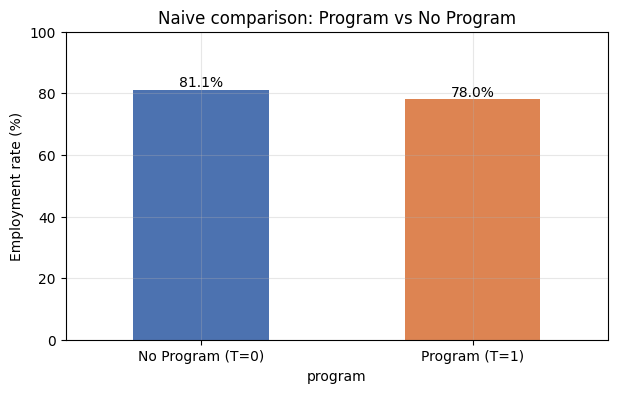

In [5]:

ax = naive_df["EmploymentRate(%)"].plot(kind="bar", color=["#4C72B0", "#DD8452"], rot=0)
ax.set_ylabel("Employment rate (%)")
ax.set_title("Naive comparison: Program vs No Program")
for i, v in enumerate(naive_df["EmploymentRate(%)"]):
    ax.text(i, v + 1, f"{v}%", ha="center")
plt.ylim(0, 100)
plt.show()


**At first glance, the program looks *worse*: 78% employment for participants vs 81% for
non‑participants.** If the agency stopped here, it might conclude the training program doesn't
work — or is even *counter‑productive* — and cancel it.

But just like the kidney‑stone example in the book, this conclusion can be an artifact of
**Simpson's paradox**. Let's stratify by education, the confounder.


In [6]:

stratified = (
    workers.groupby(["education", "program"])["employed"]
    .mean()
    .unstack("program")
    .rename(columns={0: "No Program (T=0)", 1: "Program (T=1)"})
)
(stratified * 100).round(1)


program,No Program (T=0),Program (T=1)
education,,
College,86.7,93.1
HighSchoolOnly,62.5,73.0


**Within *each* education group, the program participants have a *higher* employment rate**
(93% vs 87% for college grads; 73% vs 63% for high‑school‑only workers). The overall (naive)
comparison flipped the sign — a textbook case of **Simpson's paradox**:

> *A trend that appears within every subgroup can disappear or reverse when the subgroups
> are combined.*


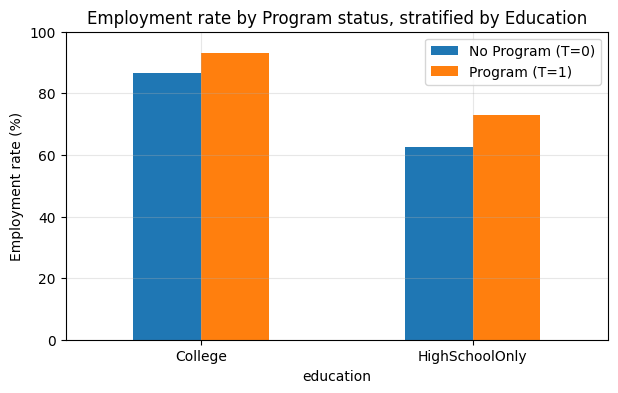

In [7]:

fig, ax = plt.subplots()
(stratified * 100).plot(kind="bar", ax=ax, rot=0)
ax.set_ylabel("Employment rate (%)")
ax.set_title("Employment rate by Program status, stratified by Education")
ax.legend(title="")
plt.ylim(0, 100)
plt.show()


### Why does this happen? Unequal selection into the program

Caseworkers assigned high‑school‑only workers (the "harder" cases, with lower baseline
employability) into the program far more often than college graduates. Let's check the
composition of each group, exactly like Figure 2.1 in the book.


In [8]:

composition = (
    workers.groupby("program")["education"]
    .value_counts(normalize=True)
    .unstack()
    .loc[[0, 1]]
    .rename(index={0: "No Program (T=0)", 1: "Program (T=1)"})
)
(composition * 100).round(1)


education,College,HighSchoolOnly
program,,
No Program (T=0),77.1,22.9
Program (T=1),24.9,75.1


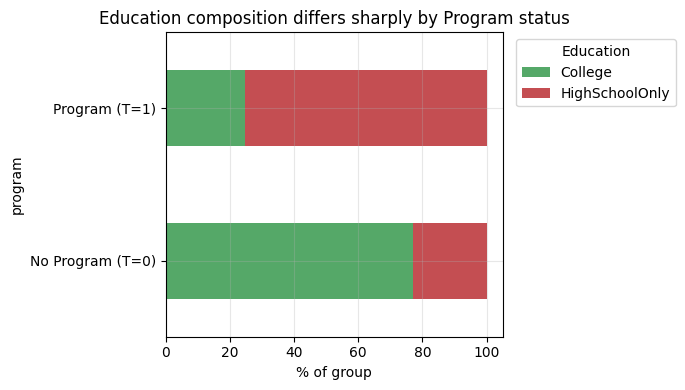

In [9]:

ax = (composition * 100).plot(kind="barh", stacked=True, color=["#55A868", "#C44E52"])
ax.set_xlabel("% of group")
ax.set_title("Education composition differs sharply by Program status")
ax.legend(title="Education", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


Whole population: about **51% college / 49% high‑school‑only**. But among program
participants, **75% have only a high‑school education**, while among non‑participants **77%
are college graduates**. Program participants are, on average, a much harder-to-place
population — which drags down their *raw* average employment rate even though the program
itself *helps* each type of worker.


## 3. Describing the problem with a causal graph

Following the book's method (step 1 of the causal-inference workflow), we encode our domain
knowledge — how caseworkers assign people to the program — into a simple causal graph:

```
        Education (E)
          /        \
         v           v
  Program (T)  --->  Employed (Y)
```

* `Education -> Program`: caseworkers use education (and related soft signals) to decide who
  needs the program.
* `Education -> Employed`: education independently affects the probability of finding a job.
* `Program -> Employed`: the causal effect we actually want to measure.

`Education` is a **confounder**: it's a common cause of both the treatment (`Program`) and the
outcome (`Employed`), so a naive comparison of averages is biased — exactly the situation
described in the "Confounding" box of the chapter.


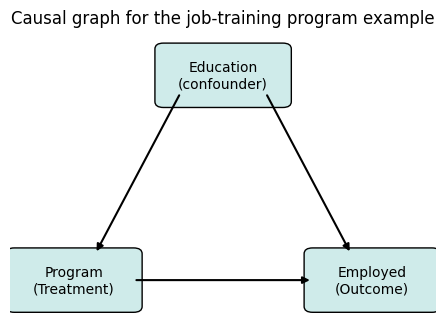

In [10]:

import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(5.5, 3.8))
ax.axis("off")

boxes = {
    "E": (0.5, 0.85, "Education\n(confounder)"),
    "T": (0.15, 0.15, "Program\n(Treatment)"),
    "Y": (0.85, 0.15, "Employed\n(Outcome)"),
}
for key, (x, y, label) in boxes.items():
    ax.add_patch(mpatches.FancyBboxPatch((x - 0.14, y - 0.09), 0.28, 0.18,
                                          boxstyle="round,pad=0.02",
                                          facecolor="#CFEBEA", edgecolor="black"))
    ax.text(x, y, label, ha="center", va="center", fontsize=10)

def arrow(p1, p2):
    ax.annotate("", xy=p2, xytext=p1,
                arrowprops=dict(arrowstyle="-|>", lw=1.5, color="black"))

arrow((0.40, 0.79), (0.20, 0.24))   # E -> T
arrow((0.60, 0.79), (0.80, 0.24))   # E -> Y
arrow((0.29, 0.15), (0.71, 0.15))   # T -> Y

ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title("Causal graph for the job-training program example")
plt.show()


## 4. Applying the adjustment formula

We want to know what would happen **if everyone in the population received the program**
(`do(Program = 1)`) versus **if nobody did** (`do(Program = 0)`). This is the *interventional*
quantity `P(Employed = 1 | do(Program = t))`, as opposed to the merely *observed*
`P(Employed = 1 | Program = t)`.

The **adjustment formula** lets us compute the interventional quantity from observational data:

$$
P(Y=1\mid \operatorname{do}(T=t)) = \sum_{e} P(Y=1\mid T=t, E=e)\, P(E=e)
$$

In words: *reweight the employment rate within each education stratum by the education
distribution of the **whole population**, not just the sub-population that happened to receive
that treatment.*


In [11]:

def adjustment_formula(df, treatment_col, outcome_col, confounder_col, treatment_value):
    '''Estimate P(Y=1 | do(T = treatment_value)) using the adjustment formula.'''
    overall_confounder_dist = df[confounder_col].value_counts(normalize=True)

    total = 0.0
    for level, p_level in overall_confounder_dist.items():
        stratum = df[(df[confounder_col] == level) & (df[treatment_col] == treatment_value)]
        efficacy = stratum[outcome_col].mean()
        total += efficacy * p_level
    return total

p_do_program1 = adjustment_formula(workers, "program", "employed", "education", 1)
p_do_program0 = adjustment_formula(workers, "program", "employed", "education", 0)
ATE_adjusted = p_do_program1 - p_do_program0

print(f"P(Employed | do(Program=1)) = {p_do_program1:.3f}")
print(f"P(Employed | do(Program=0)) = {p_do_program0:.3f}")
print(f"Average Treatment Effect (adjustment formula) = {ATE_adjusted:+.3f}  ({ATE_adjusted*100:+.1f} pp)")


P(Employed | do(Program=1)) = 0.833
P(Employed | do(Program=0)) = 0.748
Average Treatment Effect (adjustment formula) = +0.084  (+8.4 pp)


Compare this to the (biased) naive difference in means we computed in Section 2:


In [12]:

naive_diff = naive["Program (T=1)"] - naive["No Program (T=0)"]
comparison = pd.DataFrame({
    "Estimate": ["Naive difference in means", "Adjustment formula (true ATE)"],
    "Employment effect of the program (pp)": [naive_diff * 100, ATE_adjusted * 100],
})
comparison


,Estimate,Employment effect of the program (pp)
0,Naive difference in means,-3.143
1,Adjustment formula (true ATE),8.430


**The naive estimate says the program *hurts* employment by ~3 percentage points. The
adjustment formula — which properly accounts for the confounder — says the program *helps*
employment by about +9 percentage points.** This is the whole point of the chapter: without
adjusting for confounders, an economist could recommend **cancelling a program that is
actually working**.


## 5. Validating with a simulated "ground truth" (the structural approach)

Because in the real world we can never re-run history, we can't directly check whether our
adjustment-formula estimate equals the *true* causal effect. But we *can* check our method
using **simulated data**, where we control the data-generating process and can literally
simulate the intervention `do(Program = t)` for everyone — exactly as in Section 2.4 of the
book.

We define structural equations:

$$
E := U_E \qquad T := g(E, U_T) \qquad Y := f(E, T, U_Y)
$$


In [13]:

def draw_education(n):
    u0 = rng.uniform(size=n)
    return np.where(u0 < 0.51, "College", "HighSchoolOnly")

def g_assign_program(education, u1):
    '''Assignment mechanism used historically by caseworkers (matches the observed data).'''
    prob_program = np.where(education == "College", 87/357, 263/343)
    return np.where(u1 < prob_program, 1, 0)

def f_employment(education, program, u2):
    '''True (unknown in real life) causal mechanism for employment.'''
    prob = np.where(
        education == "College",
        np.where(program == 1, 0.93, 0.87),
        np.where(program == 1, 0.73, 0.63),
    )
    return np.where(u2 < prob, 1, 0)

N = 200_000

# 1) Observational world (mirrors historical assignment)
education = draw_education(N)
u1 = rng.uniform(size=N)
program_obs = g_assign_program(education, u1)
u2 = rng.uniform(size=N)
employed_obs = f_employment(education, program_obs, u2)
sim_observational = pd.DataFrame({"education": education, "program": program_obs, "employed": employed_obs})

print("Simulated observational employment rate by program status:")
print((sim_observational.groupby("program")["employed"].mean() * 100).round(1))


Simulated observational employment rate by program status:
program
0    81.7
1    78.0
Name: employed, dtype: float64


In [14]:

# 2) Intervened worlds: do(Program = 1) and do(Program = 0) for EVERYONE
education_A = draw_education(N)
employed_A = f_employment(education_A, np.ones(N, dtype=int), rng.uniform(size=N))

education_B = draw_education(N)
employed_B = f_employment(education_B, np.zeros(N, dtype=int), rng.uniform(size=N))

true_p_do_1 = employed_A.mean()
true_p_do_0 = employed_B.mean()
true_ATE = true_p_do_1 - true_p_do_0

print(f"TRUE  P(Employed | do(Program=1)) = {true_p_do_1:.3f}")
print(f"TRUE  P(Employed | do(Program=0)) = {true_p_do_0:.3f}")
print(f"TRUE  ATE (ground truth, from simulation)          = {true_ATE:+.3f}")
print(f"ADJUSTMENT-FORMULA ATE (estimated earlier from data) = {ATE_adjusted:+.3f}")


TRUE  P(Employed | do(Program=1)) = 0.831
TRUE  P(Employed | do(Program=0)) = 0.752
TRUE  ATE (ground truth, from simulation)          = +0.079
ADJUSTMENT-FORMULA ATE (estimated earlier from data) = +0.084


The adjustment-formula estimate computed from the (much smaller) observational sample
closely matches the **true** ATE obtained by literally simulating the intervention on a huge
population. This confirms that, *given the causal graph is correct*, the adjustment formula
recovers the true causal effect from observational data alone.

We can also verify the "RCT equivalence" property from Section 2.3 of the book: randomizing
`Program` (instead of letting education determine it) should give the same answer as `do()`.


In [15]:

education_rct = draw_education(N)
program_rct = rng.integers(0, 2, size=N)  # 50/50 random assignment, independent of education
employed_rct = f_employment(education_rct, program_rct, rng.uniform(size=N))

sim_rct = pd.DataFrame({"education": education_rct, "program": program_rct, "employed": employed_rct})
rct_rates = sim_rct.groupby("program")["employed"].mean()
print("Simulated RCT employment rate by program status:")
print((rct_rates * 100).round(1))
print(f"RCT-based ATE = {(rct_rates[1] - rct_rates[0]):+.3f}  (should match the true ATE above)")


Simulated RCT employment rate by program status:
program
0    75.3
1    83.2
Name: employed, dtype: float64
RCT-based ATE = +0.079  (should match the true ATE above)


## 6. Checking the positivity assumption

The adjustment formula silently requires the **positivity assumption**: for every value of the
confounder, we must have observed *both* treatment levels in the data. If, say, caseworkers
*never* enrolled college graduates in the program, we would have no information about
`P(Employed | Program=1, Education=College)`, and the formula would be undefined for that
stratum.


In [16]:

positivity_check = (
    workers.groupby(["education", "program"]).size().unstack("program")
    .rename(columns={0: "No Program (T=0)", 1: "Program (T=1)"})
)
print(positivity_check)

ok = (positivity_check > 0).all().all()
print(f"\nPositivity assumption holds for every stratum: {ok}")


program         No Program (T=0)  Program (T=1)
education                                      
College                      270             87
HighSchoolOnly                80            263

Positivity assumption holds for every stratum: True


Both cells are strictly positive for every education level, so the positivity assumption
holds and the adjustment formula is well defined here. In real economic evaluations this check
matters a lot — e.g. if a program is *only* offered to people below a certain income threshold,
you cannot estimate its effect for people above that threshold using the adjustment formula,
no matter how much data you collect.


## 7. A more realistic setting: several confounders and a continuous outcome (wages)

Real program evaluations rarely have a single binary confounder. Let's extend the example to a
setting closer to real applied labor economics:

* Confounders: **Age**, **Years of prior work experience**, **Education** (College / High
  school only).
* Treatment: still `Program` (enrolled / not enrolled).
* Outcome: now a **continuous** variable, **monthly wage (USD)** 6 months after the program —
  this is the kind of variable studied in classic program-evaluation studies (e.g. the
  National Supported Work Demonstration analyzed by LaLonde, 1986).

With several confounders (some continuous), we can no longer just build a simple cross-tab —
this is exactly where the book points forward to **regression / machine-learning-based
adjustment** (Chapters 4 and 6). We'll use a simple **linear regression** to implement the
adjustment formula via *g-computation*:

$$
E[\text{Wage} \mid \operatorname{do}(\text{Program}=t)]
   = \frac{1}{n}\sum_{i=1}^n \widehat{E}[\text{Wage}_i \mid \text{Program}=t, \mathbf{X}_i]
$$

i.e., fit a model of wages on `(Program, Age, Experience, Education)`, then predict everyone's
wage twice — once forcing `Program=1` for everybody, once forcing `Program=0` — and average.


In [17]:

n = 5000

age = rng.integers(18, 60, size=n)
experience = np.clip(rng.normal(age - 22, 4), 0, None).round(1)
education_ms = rng.choice(["HighSchoolOnly", "College"], size=n, p=[0.55, 0.45])

# Program enrollment probability depends on age, experience, education (confounding)
logit_program = (
    -1.0
    + 0.9 * (education_ms == "HighSchoolOnly")
    - 0.03 * experience
    - 0.01 * (age - 35)
)
prob_program = 1 / (1 + np.exp(-logit_program))
program_ms = rng.binomial(1, prob_program)

# True wage-generating process (unknown to the analyst in real life)
noise = rng.normal(0, 150, size=n)
true_program_effect = 250  # dollars/month -- the TRUE causal effect we want to recover
wage = (
    1800
    + 15 * experience
    + 400 * (education_ms == "College")
    + 5 * (age - 35)
    + true_program_effect * program_ms
    + noise
)

econ_data = pd.DataFrame({
    "age": age, "experience": experience, "education": education_ms,
    "program": program_ms, "wage": wage.round(0)
})
econ_data.head()


,age,experience,education,program,wage
0,41,17.7,College,0,2244.0
1,27,6.8,HighSchoolOnly,0,1615.0
2,36,22.5,College,0,2509.0
3,30,9.2,College,1,2753.0
4,59,33.0,HighSchoolOnly,0,2563.0


In [18]:

naive_wage_diff = (
    econ_data.loc[econ_data.program == 1, "wage"].mean()
    - econ_data.loc[econ_data.program == 0, "wage"].mean()
)
print(f"Naive difference in mean wages (Program - No Program) = ${naive_wage_diff:,.0f} / month")
print(f"(True causal effect used to simulate the data           = ${true_program_effect:,.0f} / month)")


Naive difference in mean wages (Program - No Program) = $50 / month
(True causal effect used to simulate the data           = $250 / month)


As expected, the naive comparison is biased downward because the program disproportionately
enrolls workers who are, on average, less experienced and less educated (and thus would earn
less regardless of the program). Now let's adjust for the confounders using **linear
regression g-computation**.


In [19]:

from sklearn.linear_model import LinearRegression

X_cols = ["program", "age", "experience"]
X = pd.get_dummies(econ_data[X_cols + ["education"]], columns=["education"], drop_first=True)
y = econ_data["wage"]

model = LinearRegression().fit(X, y)

# g-computation: predict wage for everyone under do(Program=1) and do(Program=0)
X_do1 = X.copy(); X_do1["program"] = 1
X_do0 = X.copy(); X_do0["program"] = 0

wage_hat_do1 = model.predict(X_do1).mean()
wage_hat_do0 = model.predict(X_do0).mean()
ATE_wage = wage_hat_do1 - wage_hat_do0

print(f"E[Wage | do(Program=1)]  = ${wage_hat_do1:,.0f}")
print(f"E[Wage | do(Program=0)]  = ${wage_hat_do0:,.0f}")
print(f"Adjusted ATE (g-computation)  = ${ATE_wage:,.0f} / month")
print(f"Naive difference in means     = ${naive_wage_diff:,.0f} / month")
print(f"True effect used in simulation = ${true_program_effect:,.0f} / month")


E[Wage | do(Program=1)]  = $2,500
E[Wage | do(Program=0)]  = $2,253
Adjusted ATE (g-computation)  = $248 / month
Naive difference in means     = $50 / month
True effect used in simulation = $250 / month


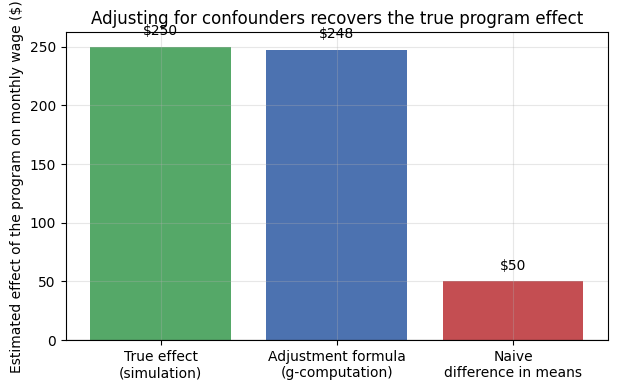

In [20]:

fig, ax = plt.subplots()
labels = ["True effect\n(simulation)", "Adjustment formula\n(g-computation)", "Naive\ndifference in means"]
values = [true_program_effect, ATE_wage, naive_wage_diff]
colors = ["#55A868", "#4C72B0", "#C44E52"]
ax.bar(labels, values, color=colors)
ax.set_ylabel("Estimated effect of the program on monthly wage ($)")
ax.set_title("Adjusting for confounders recovers the true program effect")
ax.axhline(0, color="black", linewidth=0.8)
for i, v in enumerate(values):
    ax.text(i, v + (10 if v >= 0 else -25), f"${v:,.0f}", ha="center")
plt.show()


The regression-adjusted (g-computation) estimate is very close to the true simulated effect,
while the naive comparison substantially understates the program's benefit. This mirrors
exactly the lesson of Section 2.5.5 of the book ("Many confounders"): with several
confounders — some of them continuous — we move from the simple adjustment formula to
model-based adjustment (here, linear regression; in Chapter 4 of the book, machine-learning
models), but the underlying logic is identical.


## 8. A common economics pitfall: don't adjust for mediators

Suppose the training program also grants participants an **official skills certificate**, and
we noticed that people with the certificate earn more. It might be tempting to "control for
certificate status" in the wage regression to get a "cleaner" estimate.

**This would be a mistake.** The certificate is not a confounder — it is a **mediator**: the
program *causes* the certificate, which in turn *causes* higher wages. This is exactly Section
2.5.4 of the book:

```
Program (T)  --->  Certificate (M)  --->  Wage (Y)
     \_____________________________________/
                    (direct effect)
```

If we condition on the certificate, we would be **blocking part of the very causal pathway
we're trying to measure**, and our estimate of the program's effect would be biased toward
zero — understating how much the program actually helps. In applied economics this mistake is
common: analysts "control for" outcomes of the treatment itself (post-treatment variables like
promotions, certifications, or hours worked) and inadvertently wipe out much of the effect they
are trying to measure.

**Rule of thumb reproduced from the book (Table 2.7):**

| Variable type | Adjust for it? |
|---|---|
| Confounder (affects both `T` and `Y`) | **Yes** — required |
| Missing/unobserved confounder | Should, but can't — biggest threat to validity |
| Mediator (`T` causes it, it causes `Y`) | **No** — introduces bias |
| Outcome-predictive variable (affects only `Y`) | Optional — improves precision |
| Treatment-predictive variable (affects only `T`) | Not recommended — can hurt precision |


## 9. Summary — lessons for applied economics

1. **Never trust a raw comparison of averages in observational (non-experimental) economic
   data.** As Simpson's paradox showed, the sign of an effect can flip once you account for who
   selects into the "treatment" (a program, a policy, a new technology, etc.).
2. **The adjustment formula lets us estimate the causal effect (the ATE) from observational
   data**, *provided* we correctly identify and measure the relevant confounders
   (`P(Y|do(T=t)) = Σ_x P(Y|T=t, X=x) P(X=x)`).
3. **Domain knowledge is what tells us which variables are confounders** (must adjust),
   mediators (must NOT adjust), or merely predictive (optional). Getting this wrong — e.g.
   controlling for a mediator like a certificate obtained through the program — silently biases
   the estimated policy effect.
4. **The positivity assumption must hold**: every subgroup of interest must contain both
   "treated" and "untreated" individuals in the data, or the causal effect for that subgroup
   simply cannot be estimated from observational data.
5. **Randomized Controlled Trials (RCTs) — the "gold standard" in program evaluation
   economics** (e.g. randomized job-training pilots, conditional cash-transfer RCTs in
   development economics) — sidestep the entire confounding problem, because random assignment
   guarantees `P(Y|do(T=t)) = P(Y|T=t)`. When an RCT isn't feasible or ethical, the adjustment
   formula (and its machine-learning generalizations, covered later in the book) is the tool
   economists reach for to approximate what an RCT would have shown.

This is a small-scale illustration of the workflow used throughout applied microeconomics and
policy evaluation: labor-training programs, minimum-wage studies, education interventions,
microfinance programs, and public-health policies are all routinely analyzed with exactly this
toolkit — draw the causal graph, identify confounders vs. mediators, check positivity, and
apply the adjustment formula (or its ML-based extensions) instead of naive averages.
